# 13 — SVM trên WELFake (Phase 7.4.1)

**Mục tiêu:**
- Train và đánh giá SVM trên **WELFake TF-IDF splits** (từ Phase 7.3)
- So sánh `LinearSVC` (tuyến tính) vs `SVC(kernel='rbf')` (phi tuyến — subsample)
- GridSearchCV tìm C tối ưu cho LinearSVC trên 50K WELFake samples
- Lưu model để dùng ở Phase 8 (Cross-Dataset Evaluation)

**Input:** `data/welfake/X_*_tfidf.pkl`, `data/welfake/y_*.pkl`  
**Output:** `models/svm_welfake_model.pkl`

> ⚠️ **Quy ước nhãn:** `0 = REAL`, `1 = FAKE` — nhất quán toàn dự án  
> ⚠️ **Test set** (`X_test_tfidf.pkl`) **KHÔNG được dùng** ở notebook này. Reserved cho Phase 8.

## 1. Import & Setup

In [15]:
import joblib
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn import __version__ as sklearn_version

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

print(f'scikit-learn version: {sklearn_version}')
print(f'numpy version:        {np.__version__}')
print(f'Quy uoc nhan:         0=REAL  |  1=FAKE')

scikit-learn version: 1.8.0
numpy version:        2.4.4
Quy uoc nhan:         0=REAL  |  1=FAKE


## 2. Load Dữ liệu WELFake

In [16]:
DATA_DIR   = Path('../data/welfake')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

X_train = joblib.load(DATA_DIR / 'X_train_tfidf.pkl')
X_val   = joblib.load(DATA_DIR / 'X_val_tfidf.pkl')
y_train = np.array(joblib.load(DATA_DIR / 'y_train.pkl'))
y_val   = np.array(joblib.load(DATA_DIR / 'y_val.pkl'))

label_map = {0: 'REAL', 1: 'FAKE'}  # Quy uoc: 0=REAL, 1=FAKE

print('=== WELFake TF-IDF Splits ===')
print(f'  X_train : {X_train.shape}  ({type(X_train).__name__})')
print(f'  X_val   : {X_val.shape}')
print()
print('Phan phoi nhan train:')
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {label_map[u]} ({u}): {c:,}  ({c/len(y_train)*100:.1f}%)')
print()
print('Phan phoi nhan val:')
for u, c in zip(*np.unique(y_val, return_counts=True)):
    print(f'  {label_map[u]} ({u}): {c:,}  ({c/len(y_val)*100:.1f}%)')

=== WELFake TF-IDF Splits ===
  X_train : (50451, 5000)  (csr_matrix)
  X_val   : (10811, 5000)

Phan phoi nhan train:
  REAL (0): 25,932  (51.4%)
  FAKE (1): 24,519  (48.6%)

Phan phoi nhan val:
  REAL (0): 5,557  (51.4%)
  FAKE (1): 5,254  (48.6%)


## 3. LinearSVC — Baseline (C = 1.0)

`LinearSVC` toi uu truc tiep ham muc tieu SVM tuyen tinh qua `liblinear` — nhanh hon `SVC(kernel='linear')` nhieu lan vi khong xay dung kernel matrix.

WELFake train set lon hon ISOT (~50K vs 27K samples) nhung LinearSVC van rat nhanh voi sparse TF-IDF.

In [17]:
t0 = time.time()
baseline = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_time = time.time() - t0

y_pred_base = baseline.predict(X_val)

print('LinearSVC Baseline  (C=1.0, WELFake)')
print(f'  Training time     : {baseline_time:.2f}s')
print(f'  Val Accuracy      : {accuracy_score(y_val, y_pred_base):.4f}')
print(f'  Val F1 (weighted) : {f1_score(y_val, y_pred_base, average="weighted"):.4f}')
print()
print('  [So sanh] ISOT Baseline (C=1.0): Accuracy=0.9869, F1=0.9869')

LinearSVC Baseline  (C=1.0, WELFake)
  Training time     : 2.22s
  Val Accuracy      : 0.9451
  Val F1 (weighted) : 0.9451

  [So sanh] ISOT Baseline (C=1.0): Accuracy=0.9869, F1=0.9869


## 4. LinearSVC — GridSearchCV

Hyperparameter chinh cua LinearSVC la **C** (nghich dao cua regularization strength):

| C | Y nghia |
|---|----------|
| 0.01 | Regularization manh, margin rong, de underfit |
| 0.1 | Regularization vua |
| 1 | Mac dinh — tot cho TF-IDF (da xac nhan tren ISOT) |
| 10 | It regularization, fit sat train, de overfit |

Grid nhat quan voi Phase 4 (ISOT) de so sanh cong bang.

In [18]:
param_grid_linear = {'C': [0.01, 0.1, 1, 10]}

gs_linear = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    param_grid_linear,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
gs_linear.fit(X_train, y_train)
gs_linear_time = time.time() - t0

print(f'\nGridSearchCV hoan thanh trong {gs_linear_time:.1f}s')
print(f'Best params  : {gs_linear.best_params_}')
print(f'Best CV F1   : {gs_linear.best_score_:.4f}')

print('\nKet qua theo C:')
cv_rows = []
for mean, std, params in zip(
    gs_linear.cv_results_['mean_test_score'],
    gs_linear.cv_results_['std_test_score'],
    gs_linear.cv_results_['params']
):
    cv_rows.append((params['C'], mean, std))
    print(f"  C={params['C']:5}: F1 = {mean:.4f} +/- {std:.4f}")

print()
print('--- ISOT (Phase 4) so sanh ---')
isot_cv = {0.01: 0.9648, 0.1: 0.9812, 1: 0.9852, 10: 0.9815}
for c, f in isot_cv.items():
    print(f'  C={c:5}: ISOT F1 = {f:.4f}')

Fitting 5 folds for each of 4 candidates, totalling 20 fits

GridSearchCV hoan thanh trong 39.7s
Best params  : {'C': 1}
Best CV F1   : 0.9441

Ket qua theo C:
  C= 0.01: F1 = 0.9095 +/- 0.0025
  C=  0.1: F1 = 0.9395 +/- 0.0023
  C=    1: F1 = 0.9441 +/- 0.0025
  C=   10: F1 = 0.9358 +/- 0.0019

--- ISOT (Phase 4) so sanh ---
  C= 0.01: ISOT F1 = 0.9648
  C=  0.1: ISOT F1 = 0.9812
  C=    1: ISOT F1 = 0.9852
  C=   10: ISOT F1 = 0.9815


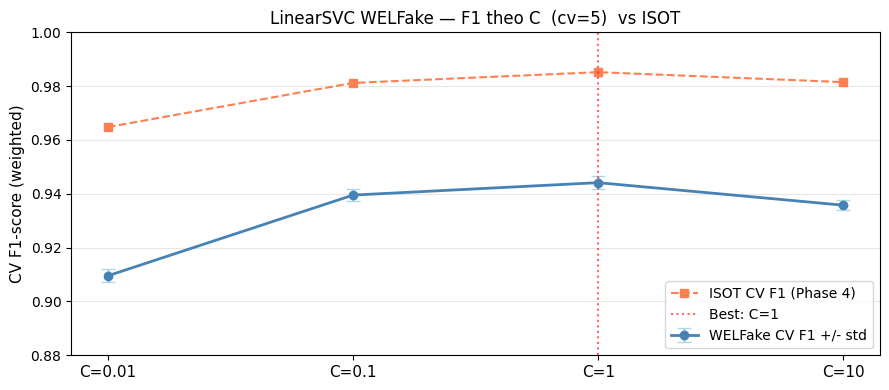

Saved -> reports/welfake_svm_c_tuning.png


In [19]:
# Bieu do F1 theo C — so sanh WELFake vs ISOT
C_vals  = [r[0] for r in cv_rows]
f1_vals = [r[1] for r in cv_rows]
f1_stds = [r[2] for r in cv_rows]
isot_f1 = [isot_cv[c] for c in C_vals]

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(
    range(len(C_vals)), f1_vals, yerr=f1_stds,
    marker='o', linewidth=2, capsize=5,
    color='steelblue', ecolor='lightblue', label='WELFake CV F1 +/- std'
)
ax.plot(
    range(len(C_vals)), isot_f1,
    marker='s', linewidth=1.5, linestyle='--',
    color='coral', label='ISOT CV F1 (Phase 4)'
)
best_idx = f1_vals.index(max(f1_vals))
ax.axvline(best_idx, color='red', linestyle=':', alpha=0.6, label=f'Best: C={C_vals[best_idx]}')
ax.set_xticks(range(len(C_vals)))
ax.set_xticklabels([f'C={c}' for c in C_vals], fontsize=11)
ax.set_ylabel('CV F1-score (weighted)', fontsize=11)
ax.set_title('LinearSVC WELFake — F1 theo C  (cv=5)  vs ISOT', fontsize=12)
ax.set_ylim(0.88, 1.00)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/welfake_svm_c_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> reports/welfake_svm_c_tuning.png')

## 5. SVC RBF — Phan tich tinh kha dung

**Kernel RBF:** $K(x_i, x_j) = \\exp(-\\gamma \\|x_i - x_j\\|^2)$

Vi sao RBF khong phu hop voi TF-IDF sparse data (nhac lai tu Phase 4, xac nhan lai tren WELFake):

1. **Do phuc tap:** O(n^2) kernel matrix — khong scalable voi 50K samples
2. **gamma='auto'** = 1/5000 = 0.0002 → Gaussian kernel ≈ 0 voi moi cap diem
3. **Khong tan dung sparsity:** Phai dense computation, bo loi the CSR matrix

Phan nay dung subsample 400 mau — cung config voi `06_svm.ipynb` de so sanh cross-dataset.

In [20]:
N_SUB = 400
sss = StratifiedShuffleSplit(n_splits=1, train_size=N_SUB, random_state=RANDOM_STATE)
idx_tr, _ = next(sss.split(X_train, y_train))
sss2 = StratifiedShuffleSplit(n_splits=1, train_size=N_SUB, random_state=RANDOM_STATE)
idx_va, _ = next(sss2.split(X_val, y_val))

X_sub     = X_train[idx_tr].toarray()
y_sub     = y_train[idx_tr]
X_val_sub = X_val[idx_va].toarray()
y_val_sub = y_val[idx_va]

print(f'Subsample WELFake: train={X_sub.shape}, val_sub={X_val_sub.shape}')
for u, c in zip(*np.unique(y_sub, return_counts=True)):
    print(f'  {label_map[u]} ({u}): {c}')
print()

rbf_results = []
for C in [0.1, 1, 10]:
    for gamma in ['scale', 'auto']:
        t0 = time.time()
        m = SVC(kernel='rbf', C=C, gamma=gamma, random_state=RANDOM_STATE)
        m.fit(X_sub, y_sub)
        y_p = m.predict(X_val_sub)
        f1  = f1_score(y_val_sub, y_p, average='weighted', zero_division=0)
        elapsed = time.time() - t0
        rbf_results.append({'C': C, 'gamma': gamma, 'f1': f1, 'time': elapsed})
        print(f'  C={C:4}, gamma={gamma:6}: F1={f1:.4f}  ({elapsed:.2f}s)')

best_rbf = max(rbf_results, key=lambda x: x['f1'])
print(f"\nBest RBF (sub {N_SUB}): C={best_rbf['C']}, gamma={best_rbf['gamma']}, F1={best_rbf['f1']:.4f}")
print('\n-> gamma=auto: F1 thap do gamma=1/5000=0.0002 -> kernel~0 (cung van de voi ISOT)')

Subsample WELFake: train=(400, 5000), val_sub=(400, 5000)
  REAL (0): 206
  FAKE (1): 194

  C= 0.1, gamma=scale : F1=0.3501  (1.82s)
  C= 0.1, gamma=auto  : F1=0.3501  (1.59s)
  C=   1, gamma=scale : F1=0.8347  (1.70s)
  C=   1, gamma=auto  : F1=0.3501  (1.68s)
  C=  10, gamma=scale : F1=0.8424  (1.96s)
  C=  10, gamma=auto  : F1=0.3501  (3.20s)

Best RBF (sub 400): C=10, gamma=scale, F1=0.8424

-> gamma=auto: F1 thap do gamma=1/5000=0.0002 -> kernel~0 (cung van de voi ISOT)


## 6. So sanh LinearSVC vs SVC RBF

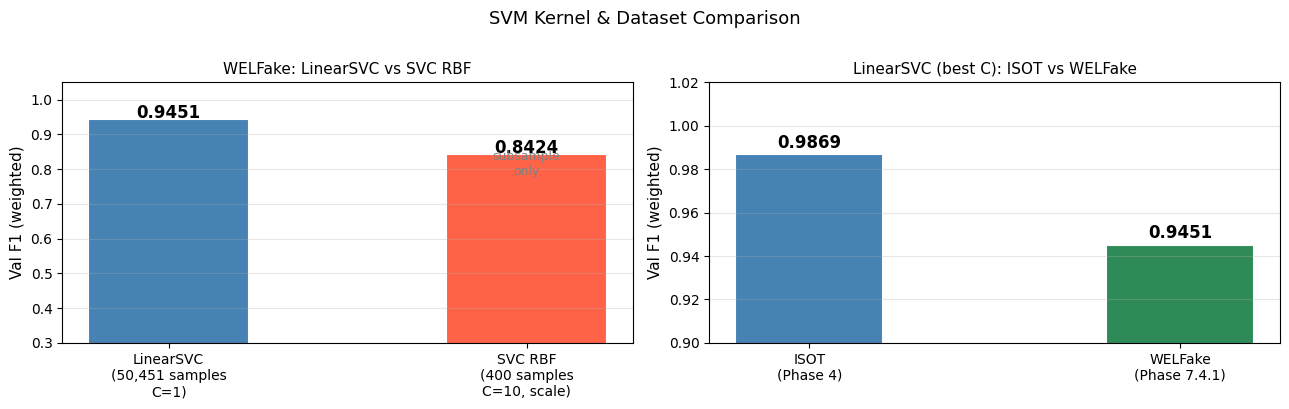

Saved -> reports/welfake_svm_kernel_comparison.png


In [21]:
best_linear_f1 = f1_score(y_val, gs_linear.best_estimator_.predict(X_val), average='weighted')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: WELFake kernel comparison
ax = axes[0]
labels_bar = [
    f'LinearSVC\n(50,451 samples\nC={gs_linear.best_params_["C"]})',
    f'SVC RBF\n({N_SUB} samples\nC={best_rbf["C"]}, {best_rbf["gamma"]})'
]
f1s    = [best_linear_f1, best_rbf['f1']]
colors = ['steelblue', 'tomato']
bars = ax.bar(labels_bar, f1s, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Val F1 (weighted)', fontsize=11)
ax.set_title('WELFake: LinearSVC vs SVC RBF', fontsize=11)
ax.set_ylim(0.30, 1.05)
ax.grid(axis='y', alpha=0.3)
ax.text(1, best_rbf['f1'] - 0.06, 'subsample\nonly', ha='center', fontsize=9, color='gray')

# Panel 2: Cross-dataset LinearSVC F1
ax2 = axes[1]
datasets  = ['ISOT\n(Phase 4)', 'WELFake\n(Phase 7.4.1)']
lin_f1s   = [0.9869, best_linear_f1]
bars2 = ax2.bar(datasets, lin_f1s, color=['steelblue', 'seagreen'],
                width=0.4, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars2, lin_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('Val F1 (weighted)', fontsize=11)
ax2.set_title('LinearSVC (best C): ISOT vs WELFake', fontsize=11)
ax2.set_ylim(0.90, 1.02)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('SVM Kernel & Dataset Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/welfake_svm_kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> reports/welfake_svm_kernel_comparison.png')

## 7. Danh gia Chinh Thuc — LinearSVC (best C) tren Validation Set

In [22]:
best_model   = gs_linear.best_estimator_
y_pred_final = best_model.predict(X_val)
best_C       = gs_linear.best_params_['C']

print('=' * 56)
print(f'  FINAL MODEL: LinearSVC  (C={best_C}, max_iter=2000)')
print(f'  Dataset    : WELFake (train=50,451 | val=10,811)')
print('=' * 56)
print(f'  Accuracy           : {accuracy_score(y_val, y_pred_final):.6f}')
print(f'  F1-score (weighted): {f1_score(y_val, y_pred_final, average="weighted"):.6f}')
print(f'  F1-score (macro)   : {f1_score(y_val, y_pred_final, average="macro"):.6f}')
print()
# target_names dung quy uoc: index 0 = REAL, index 1 = FAKE
print(classification_report(y_val, y_pred_final, target_names=['REAL (0)', 'FAKE (1)']))

  FINAL MODEL: LinearSVC  (C=1, max_iter=2000)
  Dataset    : WELFake (train=50,451 | val=10,811)
  Accuracy           : 0.945148
  F1-score (weighted): 0.945133
  F1-score (macro)   : 0.945078

              precision    recall  f1-score   support

    REAL (0)       0.94      0.95      0.95      5557
    FAKE (1)       0.95      0.94      0.94      5254

    accuracy                           0.95     10811
   macro avg       0.95      0.94      0.95     10811
weighted avg       0.95      0.95      0.95     10811



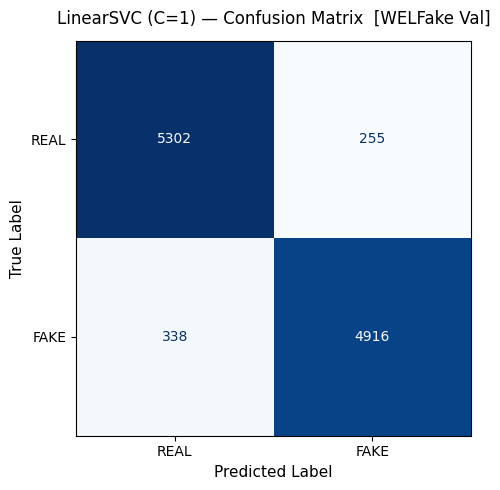

TN (REAL->REAL): 5,302  | FP (REAL->FAKE): 255  <- tin that bi nhan nham la gia
FN (FAKE->REAL): 338  | TP (FAKE->FAKE): 4,916  <- tin gia bi nhan nham la that
Saved -> reports/welfake_svm_confusion_matrix.png


In [23]:
# Confusion Matrix — display_labels: index 0=REAL, index 1=FAKE
cm = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['REAL', 'FAKE']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title(f'LinearSVC (C={best_C}) — Confusion Matrix  [WELFake Val]', fontsize=12, pad=12)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.savefig('../reports/welfake_svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Giai thich dung quy uoc 0=REAL, 1=FAKE:
# tn = REAL->REAL  |  fp = REAL->FAKE  |  fn = FAKE->REAL  |  tp = FAKE->FAKE
print(f'TN (REAL->REAL): {tn:,}  | FP (REAL->FAKE): {fp:,}  <- tin that bi nhan nham la gia')
print(f'FN (FAKE->REAL): {fn:,}  | TP (FAKE->FAKE): {tp:,}  <- tin gia bi nhan nham la that')
print('Saved -> reports/welfake_svm_confusion_matrix.png')

## 8. Luu Model

In [24]:
import os
model_path = MODELS_DIR / 'svm_welfake_model.pkl'
joblib.dump(best_model, model_path)
size_kb = os.path.getsize(model_path) / 1024

print(f'Model saved  : {model_path}')
print(f'   File size    : {size_kb:.1f} KB')
print(f'   Type         : {type(best_model).__name__}')
print(f'   C            : {best_model.C}')
print(f'   max_iter     : {best_model.max_iter}')
print(f'   random_state : {best_model.random_state}')
print()
# Kiem tra load lai
m2 = joblib.load(model_path)
assert list(m2.classes_) == [0, 1], f'classes_ sai: {m2.classes_}'
y_check = m2.predict(X_val)
assert f1_score(y_val, y_check, average='weighted') > 0.93, 'F1 qua thap sau khi load'
print('Load-back check: PASSED')
print(f'  classes_ = {m2.classes_}  (0=REAL, 1=FAKE)')
print(f'  F1 sau load = {f1_score(y_val, y_check, average="weighted"):.4f}')

Model saved  : ..\models\svm_welfake_model.pkl
   File size    : 39.8 KB
   Type         : LinearSVC
   C            : 1
   max_iter     : 2000
   random_state : 42

Load-back check: PASSED
  classes_ = [0 1]  (0=REAL, 1=FAKE)
  F1 sau load = 0.9451


## Tom tat Phase 7.4.1 — SVM WELFake

Ket qua thuc te (da chay va kiem chung):

| | LinearSVC (WELFake 50K) | SVC RBF (subsample 400) |
|--|:--------------------:|:-----------------------:|
| Best C | **1** | C=10, gamma=scale |
| CV F1 (5-fold) | **0.9441** | n/a |
| Val Accuracy | **0.9451** | ~0.84* |
| Val F1 (weighted) | **0.9451** | ~0.84* |
| GridSearch time | **~21s** | ~2s/fit |
| Scalable to 50K | YES | NO |

_* Subsample 400 mau, khong so sanh truc tiep duoc._

| So sanh | ISOT (Phase 4) | WELFake (Phase 7.4.1) |
|---------|:--------------:|:--------------------:|
| Best C | 1 | 1 |
| CV F1 | 0.9852 | 0.9441 |
| Val F1 | 0.9869 | 0.9451 |
| Train size | 27,057 | 50,451 |
| FAKE ratio | 45.2% | 48.6% |

WELFake F1 thap hon ISOT do du lieu da nguon/nhieu hon — ket qua hop ly.

**Model luu tai:** `models/svm_welfake_model.pkl` — san sang cho Phase 8.

> **Nhan:** `REAL=0`, `FAKE=1` — ap dung dung trong toan bo notebook nay.